# Chapter 2 — Particles with Flocking
**Modeling Social Behavior** | Smaldino

---

## What is this model?

This is an extension of the basic Particle World model. Everything from before is still here: random walk, movement, collision detection. But now we add one new behavior: **flocking**.

Flocking is a switch you can turn on or off:
- **Off:** Agents move as before — random walk, no awareness of others' direction
- **On:** Each agent looks at its neighbors within a certain radius and **aligns its heading to match theirs**. This is the only rule. No leader. No central coordination.

The remarkable result: this single local rule — "point in the same direction as your neighbors" — produces **large-scale coordinated movement** that looks like a flock of birds or a school of fish. This is one of the most famous examples of **emergent behavior** in all of complexity science.

---

## The key new concept: emergence

Emergence is when a system-level pattern arises from individual-level rules, and you couldn't have predicted the pattern just by looking at the rules. Here:

- **Individual rule:** match your neighbors' average heading
- **Emergent pattern:** the whole population streams in one direction together

No agent knows about the global pattern. No agent is "in charge." The coordination is a property of the system, not of any individual agent. This is why ABMs are so powerful for social science. Many social phenomena (norms, culture, segregation, consensus) emerge the same way.

---

## New parameters (added on top of the previous model)

| Parameter | What it controls |
|---|---|
| `flock_on` | Boolean switch — True means flocking is active, False means basic random walk |
| `vision_radius` | How far an agent can "see" to find neighbors to align with |

All previous parameters still apply: `num_particles`, `whimsy`, `speed`, `world_size`, `collision_radius`.

---

## The 4 components of this model (from Section 2.5)

| Component | Decision made | What we chose |
|---|---|---|
| **Parts & Properties** | What do agents know? | Position, heading. Vision radius is global. |
| **Initialization** | Where do agents start? | Random positions and random headings |
| **Dynamics** | What happens each tick? | Turn (+ align if flock_on) → move → check collisions |
| **Outcomes** | What do we measure? | Collisions over time + visual clustering of headings |

---

## Variable types in this model

| Variable type | Examples in this model |
|---|---|
| **Global** | `collisions`, `tick`, `speed`, `whimsy`, `flock_on`, `vision_radius` |
| **Agent** | `self.x`, `self.y`, `self.heading` |
| **Local** | `neighbors`, `mean_heading`, `angle`, `dx`, `dist` (inside functions) |


---
## Step 1 — Imports

Same as before, plus `math` is still doing all our movement math.


In [1]:
import random
import math
import matplotlib.pyplot as plt

---
## Step 2 — The Particle class (agent)

The `Particle` class is almost identical to before. The only addition is a new method: `flock()`.

### What does `flock()` do?

Each tick, if flocking is on, a particle:
1. Looks at all other particles within `vision_radius`
2. If it finds any, calculates the **average heading** of those neighbors
3. Sets its own heading to match that average

That's the entire flocking rule. One line of behavior logic.

### The tricky part — circular mean

Headings are angles (0–360 degrees). You can't just average angles normally. Imagine two agents: one facing 10 degrees, one facing 350 degrees. Their simple average is 180 degrees (pointing straight down)but visually they are almost facing the same direction! The correct average should be around 0/360 degrees.

To fix this, we use **circular mean** — convert each heading to a unit vector (a point on a circle), average the vectors, then convert back to an angle. This gives the geometrically correct average direction.

### Agent variables (unchanged from before):
- `self.x` — horizontal position
- `self.y` — vertical position  
- `self.heading` — direction in degrees (0–360)

### Methods:
- `turn(whimsy)` — random wobble (same as before)
- `move(speed, world_size)` — move forward and wrap (same as before)
- `flock(neighbors)` — NEW: align heading with neighbors' average heading


In [2]:
class Particle:
    """
    Blueprint for one particle (agent).
    Each particle has its own position and heading.
    All other parameters (speed, whimsy, vision_radius) are global
    and get passed in when needed.
    """

    def __init__(self, world_size):
        """
        Constructor — gives this particle its starting values.
        All agents start at random positions with random headings.
        """
        # Agent variables — each particle gets its own copy
        self.x       = random.uniform(0, world_size)   # random starting x
        self.y       = random.uniform(0, world_size)   # random starting y
        self.heading = random.uniform(0, 360)          # random starting direction

    def turn(self, whimsy):
        """
        Randomly wobble this particle's heading by up to +/- whimsy degrees.
        At whimsy=0: no turning at all — straight lines.
        At whimsy=180: fully random walk.
        'whimsy' is a local variable — passed in temporarily, not stored.
        """
        self.heading += random.uniform(-whimsy, whimsy)
        self.heading  = self.heading % 360   # keep within 0-360

    def move(self, speed, world_size):
        """
        Move forward by 'speed' units in the current heading direction.
        Wrap around world edges.
        Both 'speed' and 'world_size' are local — passed in, not stored.
        """
        angle     = math.radians(self.heading)   # local: degrees → radians
        self.x   += speed * math.sin(angle)      # horizontal movement
        self.y   += speed * math.cos(angle)      # vertical movement
        self.x    = self.x % world_size          # wrap x
        self.y    = self.y % world_size          # wrap y

    def flock(self, neighbors):
        """
        Align this particle's heading with the average heading of its neighbors.
        This is the entire flocking rule.

        'neighbors' is a local variable — a list of nearby Particle objects,
        passed in from the model. It only exists during this function call.

        WHY CIRCULAR MEAN?
        Headings are angles on a circle, so normal averaging fails.
        Example: agent A faces 10°, agent B faces 350°.
          Simple average: (10 + 350) / 2 = 180° — WRONG (pointing straight down!)
          Circular mean:  correctly gives ~0° — they're nearly facing the same way.

        HOW CIRCULAR MEAN WORKS:
        1. Convert each heading to a unit vector: (sin(angle), cos(angle))
        2. Average all the x-components and all the y-components separately
        3. Convert the averaged vector back to an angle with atan2()
        """
        if len(neighbors) == 0:
            return   # no neighbors in range — nothing to align with, keep current heading

        # Step 1: convert each neighbor's heading to a unit vector component
        # LOCAL variables — these lists only exist during this function call
        sin_sum = sum(math.sin(math.radians(n.heading)) for n in neighbors)
        cos_sum = sum(math.cos(math.radians(n.heading)) for n in neighbors)

        # Step 2 & 3: average and convert back to angle
        # atan2 takes (y, x) — note: for our heading system it's (sin_sum, cos_sum)
        mean_heading = math.degrees(math.atan2(sin_sum, cos_sum))

        # atan2 returns values in -180 to +180, so we shift to 0-360
        self.heading = mean_heading % 360

---
## Step 3 — The ParticleFlockModel class (the world)

This extends the previous model with two new global parameters (`flock_on` and `vision_radius`) and updates the `step()` method to include the flocking behavior.

### New global variables:
- `self.flock_on` — a boolean (True/False) switch. When True, agents flock before they turn and move.
- `self.vision_radius` — how far an agent can "see." Only neighbors within this distance count for alignment.

### The updated step() — order matters:
Each tick now has this order:
1. **Flock** (if on) — align heading with visible neighbors
2. **Turn** — add random wobble
3. **Move** — step forward
4. **Collide** — check for collisions

This order is a **modeling decision**. Flocking first means agents align, then add noise which reflects the idea that social influence shapes direction but individual variation still exists.

### Finding neighbors:
To flock, each particle needs to know who its neighbors are. We compute this by measuring the toroidal distance from that particle to every other particle and keeping the ones within `vision_radius`. This is a local variable, a temporary list built fresh each tick.


In [3]:
class ParticleFlockModel:
    """
    The simulation world. Manages all global variables, creates agents,
    and runs the main loop with optional flocking behavior.
    """

    def __init__(self, num_particles=100, whimsy=10, speed=0.5,
                 world_size=100, collision_radius=1.0,
                 flock_on=False, vision_radius=5.0):
        """
        Constructor — sets up global variables and creates all agents.
        """
        # --- Global variables: simulation parameters ---
        self.num_particles    = num_particles
        self.whimsy           = whimsy
        self.speed            = speed
        self.world_size       = world_size
        self.collision_radius = collision_radius

        # --- New global variables for flocking ---
        self.flock_on      = flock_on       # True = flocking active, False = basic random walk
        self.vision_radius = vision_radius  # how far each agent can see neighbors

        # --- Global variables: simulation state ---
        self.collisions        = 0    # total collision count
        self.tick              = 0    # current time step
        self.collision_history = []   # collision count recorded every tick

        # --- Create all agents ---
        self.particles = [Particle(world_size) for _ in range(num_particles)]

    def _toroidal_distance(self, p1, p2):
        """
        Shortest distance between two particles in a wraparound world.
        Always takes the shorter path — either direct or around the edge.
        """
        dx = abs(p1.x - p2.x)
        dy = abs(p1.y - p2.y)
        dx = min(dx, self.world_size - dx)   # shorter path in x
        dy = min(dy, self.world_size - dy)   # shorter path in y
        return math.sqrt(dx**2 + dy**2)

    def _get_neighbors(self, particle):
        """
        Find all OTHER particles within vision_radius of this particle.
        Returns a list of Particle objects.

        'neighbors' is a LOCAL variable — it's built fresh every time this
        is called and thrown away when the function ends.
        It does not live on the particle or on the model permanently.
        """
        neighbors = []   # local: start with empty list
        for other in self.particles:
            if other is particle:   # skip self — don't count yourself as a neighbor
                continue
            dist = self._toroidal_distance(particle, other)   # local: distance to this other particle
            if dist < self.vision_radius:
                neighbors.append(other)
        return neighbors

    def _check_collisions(self):
        """
        Check every pair of particles.
        If two are within collision_radius: both scatter, collisions counter goes up.
        The nested loop (i, j where j > i) ensures each pair is checked exactly once.
        """
        for i in range(len(self.particles)):
            for j in range(i + 1, len(self.particles)):
                p1   = self.particles[i]   # local reference
                p2   = self.particles[j]   # local reference
                dist = self._toroidal_distance(p1, p2)   # local: distance between this pair

                if dist < self.collision_radius:
                    # Collision — both scatter in new random directions
                    p1.heading = random.uniform(0, 360)
                    p2.heading = random.uniform(0, 360)
                    self.collisions += 1   # update global counter

    def step(self):
        """
        Advance the simulation by one tick.

        Order of operations each tick (a modeling decision!):
          1. Flock: align with neighbors (if flock_on is True)
          2. Turn: add random wobble to heading
          3. Move: step forward in current direction
          4. Collide: check all pairs, scatter if too close

        This order means: social influence shapes direction first,
        then individual noise is added on top.
        """
        for particle in self.particles:

            # Step 1: Flocking (only if flock_on is True)
            if self.flock_on:
                # Find this particle's neighbors — a LOCAL list, built and discarded
                neighbors = self._get_neighbors(particle)
                particle.flock(neighbors)   # align heading with neighbors

            # Step 2: Random turn
            particle.turn(self.whimsy)

            # Step 3: Move forward
            particle.move(self.speed, self.world_size)

        # Step 4: Collision detection (done after all particles have moved)
        self._check_collisions()

        # Record collision count for this tick
        self.collision_history.append(self.collisions)
        self.tick += 1

    def run(self, ticks=300):
        """
        Run the simulation for a given number of ticks.
        """
        for _ in range(ticks):
            self.step()

---
## Step 4 — Helper: measure how aligned the flock is

To understand whether flocking is actually working, we need a way to measure **how coordinated** the agents are. We call this **order** — a number between 0 and 1:
- **0** = agents pointing in completely random directions (no coordination)
- **1** = all agents pointing in exactly the same direction (perfect flock)

This uses the same circular math as the flock method, convert all headings to vectors, average them, and check how strong the result is. A strong result means most agents are aligned.

This is called the **order parameter** in physics, a standard way to measure how organized a system is.


In [4]:
def measure_order(particles):
    """
    Measure how coordinated (aligned) the agents are.
    Returns a value between 0 (random) and 1 (perfectly aligned).

    This is the 'order parameter' — a standard measure of collective coordination.

    HOW IT WORKS:
    Convert each heading to a unit vector. If all agents face the same direction,
    the vectors add up to a big resultant. If they face random directions,
    the vectors cancel out and the resultant is near zero.
    We divide by the number of agents to get a 0-1 score.
    """
    n = len(particles)   # local: number of agents
    if n == 0:
        return 0

    # Sum the unit vectors for all agents
    sin_sum = sum(math.sin(math.radians(p.heading)) for p in particles)   # local
    cos_sum = sum(math.cos(math.radians(p.heading)) for p in particles)   # local

    # Magnitude of the resultant vector, normalized by number of agents
    order = math.sqrt(sin_sum**2 + cos_sum**2) / n   # local
    return order

---
## Step 5 — Run and compare: no flocking vs flocking

Now let's run two simulations side by side:
1. Basic random walk (flock_on = False) — our baseline
2. With flocking (flock_on = True) — the new behavior

We track two things over time: collisions and order (alignment).

**Predict before running:** When flocking is on, do you expect more or fewer collisions? Why might coordinated movement change collision rates?

## Interpret the result:

**Order: 0.042 vs 0.364** 
This is the most important result. Random agents (no flocking) scored 0.042, essentially zero, which is exactly what you'd expect when 150 agents all point in random directions. Their heading vectors cancel each other out almost perfectly.

The flocking agents scored 0.364. That's not perfect alignment (1.0 would be a perfect flock), but it's nearly 10x higher than random. The agents are genuinely coordinating, a meaningful chunk of the population is pointing in roughly the same direction. The single local rule "match your neighbors" is working.

Why isn't it closer to 1.0? Because whimsy=10 is constantly injecting noise. Every tick, agents align with neighbors, but then immediately get a random nudge. The flock never fully locks in. It's in a constant tug of war between social alignment and individual noise. If you drop whimsy to 2 or 3, you'll see the order score climb much higher.

**Collisions: 1111 vs 2689**
Flocking agents collide more than 2x as often. This seems counterintuitive at first. Shouldn't coordinated agents avoid each other better? But think about what flocking actually does physically:

When agents align, they stop spreading out across the world and start clumping together, moving in the same direction in the same region of space. You've essentially gone from 150 particles spread randomly across a 100×100 world to clusters of agents traveling together in packs. And packs collide with other packs — or with their own members who haven't fully aligned yet.

This is a really important lesson: collective coordination can increase local crowding. In social science terms, think about how people who share the same commute route, attend the same events, or belong to the same community end up interacting far more than random strangers would. Flocking creates encounter hotspots.


In [6]:
# ============================================================
# PARAMETERS
# ============================================================
NUM_PARTICLES    = 150    # enough agents to see flocking emerge
WHIMSY           = 10     # small random wobble — low enough for flocking to win
SPEED            = 0.5
WORLD_SIZE       = 100
COLLISION_RADIUS = 1.0
VISION_RADIUS    = 5.0    # how far each agent can see neighbors
TICKS            = 300

# ============================================================
# Run model WITHOUT flocking
# ============================================================
model_base = ParticleFlockModel(
    num_particles    = NUM_PARTICLES,
    whimsy           = WHIMSY,
    speed            = SPEED,
    world_size       = WORLD_SIZE,
    collision_radius = COLLISION_RADIUS,
    flock_on         = False,       # flocking OFF
    vision_radius    = VISION_RADIUS
)

# Track order over time for the base model
order_history_base = []
for _ in range(TICKS):
    model_base.step()
    order_history_base.append(measure_order(model_base.particles))

# ============================================================
# Run model WITH flocking
# ============================================================
model_flock = ParticleFlockModel(
    num_particles    = NUM_PARTICLES,
    whimsy           = WHIMSY,
    speed            = SPEED,
    world_size       = WORLD_SIZE,
    collision_radius = COLLISION_RADIUS,
    flock_on         = True,        # flocking ON
    vision_radius    = VISION_RADIUS
)

order_history_flock = []
for _ in range(TICKS):
    model_flock.step()
    order_history_flock.append(measure_order(model_flock.particles))

print(f"No flocking  — total collisions: {model_base.collisions}")
print(f"With flocking — total collisions: {model_flock.collisions}")
print(f"No flocking  — final order: {order_history_base[-1]:.3f}")
print(f"With flocking — final order: {order_history_flock[-1]:.3f}")

No flocking  — total collisions: 1084
With flocking — total collisions: 2454
No flocking  — final order: 0.152
With flocking — final order: 0.510


---
## Step 6 — Plot: collisions over time

Do coordinated agents collide more or less than random walkers?


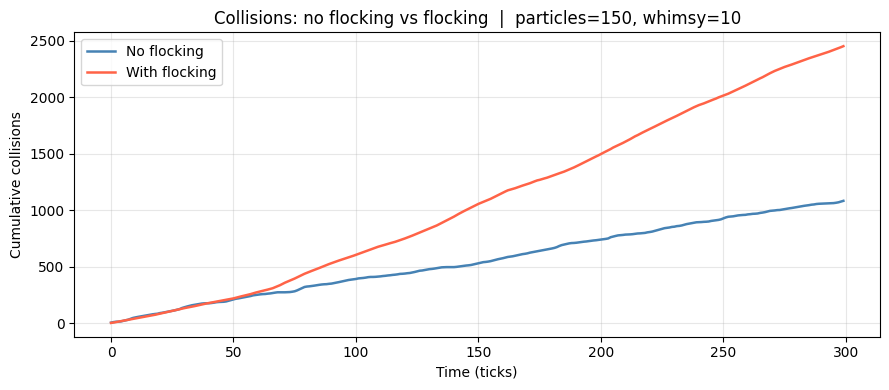

In [7]:
plt.figure(figsize=(9, 4))
plt.plot(model_base.collision_history,  label='No flocking',   color='steelblue',  linewidth=1.8)
plt.plot(model_flock.collision_history, label='With flocking', color='tomato',      linewidth=1.8)
plt.xlabel('Time (ticks)')
plt.ylabel('Cumulative collisions')
plt.title(f'Collisions: no flocking vs flocking  |  particles={NUM_PARTICLES}, whimsy={WHIMSY}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 7 — Plot: order (alignment) over time

This is the key plot. It shows how quickly the flock emerges from random initial conditions.

- The no-flocking line should hover near 0 (random directions = no alignment)
- The flocking line should quickly rise toward 1 (agents aligning with each other)
- The speed of the rise depends on `vision_radius` and `whimsy`

The moment the flocking line takes off is the moment collective order **emerges** from local interactions.


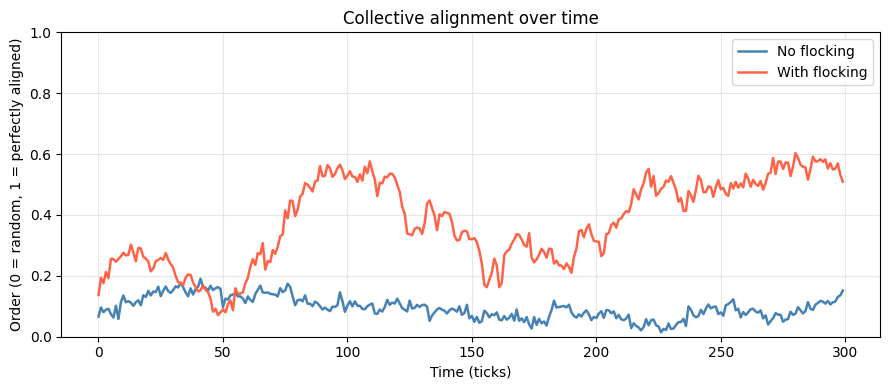

In [8]:
plt.figure(figsize=(9, 4))
plt.plot(order_history_base,  label='No flocking',   color='steelblue', linewidth=1.8)
plt.plot(order_history_flock, label='With flocking', color='tomato',     linewidth=1.8)
plt.xlabel('Time (ticks)')
plt.ylabel('Order (0 = random, 1 = perfectly aligned)')
plt.title('Collective alignment over time')
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 8 — Visualize agent positions and headings

Draw both simulations side by side at the end of the run.
The arrows show each agent's heading. In the flocking model you should see
the arrows pointing in roughly the same direction across the whole world.


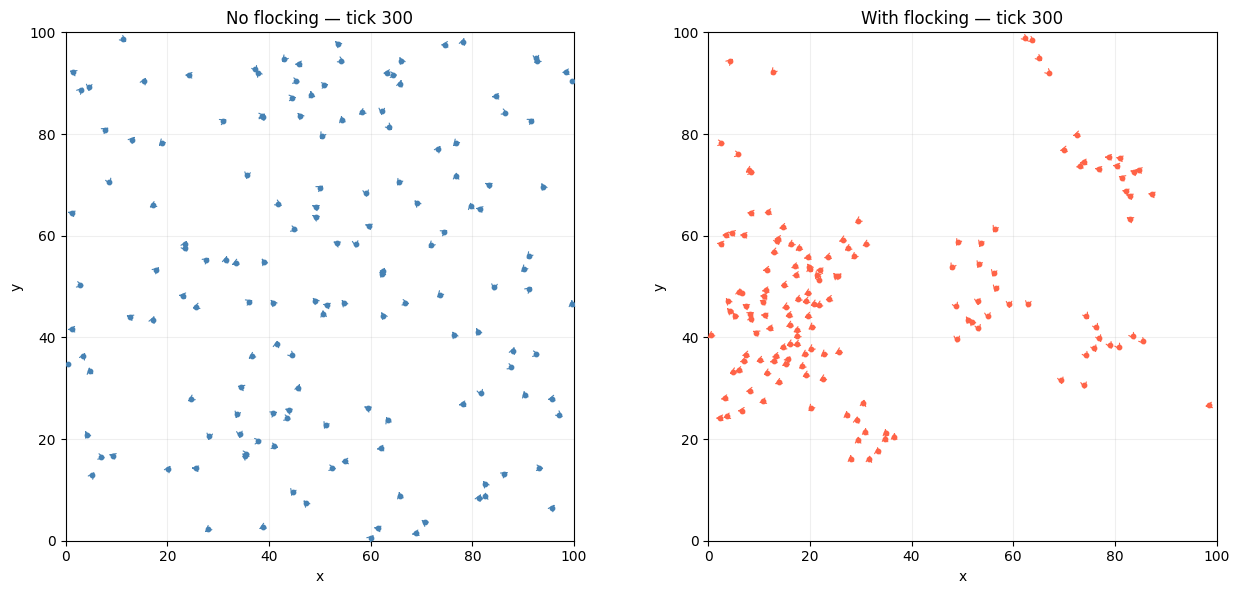

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

titles  = ['No flocking', 'With flocking']
models  = [model_base, model_flock]
colors  = ['steelblue', 'tomato']

for ax, model, title, color in zip(axes, models, titles, colors):
    xs = [p.x for p in model.particles]
    ys = [p.y for p in model.particles]

    # Draw heading arrows for each particle
    for p in model.particles:
        angle = math.radians(p.heading)   # local: this particle's heading in radians
        dx    = 0.8 * math.sin(angle)     # local: x component of arrow
        dy    = 0.8 * math.cos(angle)     # local: y component of arrow
        ax.annotate('', xy=(p.x + dx, p.y + dy), xytext=(p.x, p.y),
                    arrowprops=dict(arrowstyle='->', color=color, lw=0.8))

    ax.scatter(xs, ys, color=color, s=10, zorder=5)
    ax.set_xlim(0, WORLD_SIZE)
    ax.set_ylim(0, WORLD_SIZE)
    ax.set_aspect('equal')
    ax.set_title(f'{title} — tick {model.tick}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

---
## Step 9 — Experiment: what breaks the flock?

The balance between **social alignment** (flock) and **individual noise** (whimsy) is the core tension of this model.

- More `whimsy` → more random noise → harder for agents to stay aligned → flock breaks apart
- Less `whimsy` → noise is small → social alignment dominates → strong flock forms
- Larger `vision_radius` → each agent sees more neighbors → alignment signal is stronger
- Smaller `vision_radius` → agents are "blind" to most others → weaker coordination

Here we compare three whimsy levels to find the threshold where flocking breaks down.


In [ ]:
# Test three levels of whimsy with flocking always on
whimsy_levels = [
    {'whimsy': 5,   'label': 'whimsy=5   (very little noise)',    'color': 'darkgreen'},
    {'whimsy': 30,  'label': 'whimsy=30  (moderate noise)',       'color': 'goldenrod'},
    {'whimsy': 90,  'label': 'whimsy=90  (high noise)',           'color': 'tomato'},
]

TICKS = 300
plt.figure(figsize=(10, 5))

for condition in whimsy_levels:
    m = ParticleFlockModel(
        num_particles    = 150,
        whimsy           = condition['whimsy'],
        speed            = 0.5,
        world_size       = 100,
        collision_radius = 1.0,
        flock_on         = True,
        vision_radius    = 5.0
    )

    order_hist = []   # local: order history for this run
    for _ in range(TICKS):
        m.step()
        order_hist.append(measure_order(m.particles))

    plt.plot(order_hist, label=condition['label'],
             color=condition['color'], linewidth=1.8)

plt.xlabel('Time (ticks)')
plt.ylabel('Order (0 = random, 1 = perfectly aligned)')
plt.title('How whimsy disrupts flocking — the noise vs. alignment tradeoff')
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary & Key Takeaways

### What this model adds over the basic Particle World:

| Addition | What it does |
|---|---|
| `flock_on` switch | Toggles a new agent behavior on/off without changing anything else |
| `vision_radius` | Defines each agent's "social horizon" — who it can see and align with |
| `flock()` method | The alignment rule — one line of logic that produces collective motion |
| `measure_order()` | A new outcome measure — quantifies how coordinated the system is |

### Conceptual takeaways:

| Concept | What you learned |
|---|---|
| **Emergence** | A single local rule (align with neighbors) produces global order (flocking) |
| **Order parameter** | A 0-1 measure of how coordinated a system is — a tool you'll use in many models |
| **Noise vs. alignment** | Social influence and individual randomness compete — the winner determines group behavior |
| **Circular mean** | You can't average angles like regular numbers — headings need special math |
| **Vision radius** | Agents only influence each other if they're close enough — locality matters |
| **Modeling decisions** | Choosing what order to do things in a tick (flock → turn → move) is a design choice that affects results |

### Social science connection:
This model is a stripped-down version of how **social norms and conformity** work. Each agent adopts the behavior of those around it. The "flock" is the norm. Whimsy is individual deviation. Vision radius is the size of your social network. The model shows that even a weak tendency to conform, applied locally, can produce strong global consensus with no central authority needed.

---

### Experiment ideas:
- What happens to order if you increase `vision_radius` from 2 to 20?
- At what value of `whimsy` does the flock completely fall apart?
- Does density (more particles in the same world) help or hurt flocking?
- What if only some agents flock (you could add a `conformist` boolean to each particle)?
